# Chapter 2 — Framework 1 Execution Notebook

This notebook constructs site-level chemical stressor scores from the chemical matrix and visualizes the resulting low-score and high-score site bifurcation.

The visible execution follows:

```text
Inputs → Process → Outputs → Visualization
```

Helper tools are kept inside this notebook in collapsed **Definition Corner** cells, rather than being moved into a separate module.

# 1. Inputs

Load the site metadata and chemical matrix used for Framework 1.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

METADATA_DIR = Path("../data")
ARTIFACT_DIR = Path("../artifacts")
FIGURE_DIR = Path("../figures")
MAPS_DIR = Path("../data/maps")
RESULTS_DIR = Path("../results")

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
INFO_PATH = METADATA_DIR / "Info.xlsx"
CHEMICAL_PATH = METADATA_DIR / "M.xlsx"

print(f"Input site metadata: {INFO_PATH}")
print(f"Input chemical matrix: {CHEMICAL_PATH}")
print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"Figure directory: {FIGURE_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Input site metadata: ../data/Info.xlsx
Input chemical matrix: ../data/M.xlsx
Artifact directory: ../artifacts
Figure directory: ../figures
Results directory: ../results


In [ ]:
site_info = pd.read_excel(INFO_PATH)
site_ids = site_info["Integrated Code"].rename("Integrated Code")

chemical_raw = pd.read_excel(CHEMICAL_PATH)
chemical_with_site_id = pd.concat([site_ids, chemical_raw], axis=1)
chemical_matrix = chemical_with_site_id.set_index("Integrated Code")
chemical_columns = chemical_matrix.columns.tolist()

print(f"Loaded chemical matrix: {chemical_matrix.shape[0]} sites × {chemical_matrix.shape[1]} chemicals")
display(chemical_with_site_id.head())

Loaded chemical matrix: 310 sites × 16 chemicals


,Integrated Code,Co,Al,Ni,Mn,Fe,Cr,Cu,Hg,Pb,Zn,SumPCBs,Cd,OCS,"p,p'-DDE",As,Ca
0,DR-02,3.653624,4742.524828,4.307142,257.010460,11249.592537,12.128824,11.123978,983.426986,22.630486,18.370618,3.973114,1.270737,0.020000,0.570591,23.452117,54338.514812
1,DR-03,3.164832,3509.922179,3.394234,33.163576,8870.216287,9.578770,8.718024,648.958161,0.000400,57.245478,0.814339,0.224713,0.010000,0.182532,0.832938,48502.333729
2,DR-04,2.984709,3670.729827,2.253268,112.384890,6549.446418,9.044796,4.487565,580.952357,13.744258,23.481343,2.205706,0.673739,0.024000,0.391947,12.978875,16074.532338
3,DR-06,10.625940,20375.805889,17.585138,370.886050,24168.147789,32.899916,31.173849,4598.878590,47.078350,309.312825,6.013083,3.066512,0.872571,1.147528,45.729737,53759.041444
4,DR-07,3.549781,3827.601114,2.097337,89.789433,9337.299435,9.366623,12.489613,699.597478,19.450930,33.672548,0.730278,1.103482,0.216029,0.168522,23.179911,30206.202843


# 2. Definition Corner

The following cell defines local helper tools used later. It is intentionally kept inside the notebook, but it can be collapsed or hidden during presentation/export.

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Tuple

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import geopandas as gpd
except ImportError:
    gpd = None


def validate_chemical_matrix(matrix: pd.DataFrame, expected_n_chemicals: int = 16) -> None:
    """Validate the chemical matrix before transformation and PCA."""
    if matrix.shape[1] != expected_n_chemicals:
        raise ValueError(
            f"Expected {expected_n_chemicals} chemical variables for correlation-based PCA, "
            f"found {matrix.shape[1]}."
        )
    if matrix.isna().any().any():
        missing = int(matrix.isna().sum().sum())
        raise ValueError(f"Chemical matrix contains {missing} missing values. Handle them before PCA.")
    if (matrix < 0).any().any():
        raise ValueError("log10(x + 1) transformation requires nonnegative chemical values.")


def log10_plus_one_transformer(matrix: pd.DataFrame) -> pd.DataFrame:
    """Compress raw chemical magnitudes with log10(x + 1)."""
    return np.log10(matrix + 1.0)


def zscore_standardizer(matrix: pd.DataFrame) -> pd.DataFrame:
    """Column-standardize a matrix to mean 0 and sample standard deviation 1."""
    return (matrix - matrix.mean()) / matrix.std(ddof=1)


def correlation_matrix_constructor(transformed_matrix: pd.DataFrame) -> pd.DataFrame:
    """Construct the variable-by-variable correlation matrix."""
    return transformed_matrix.corr()


def principal_component_analysis(
    correlation_matrix: pd.DataFrame,
    min_eigenvalue: float = 1.0,
) -> pd.DataFrame:
    """Return raw PCA loadings retained by the Kaiser eigenvalue > 1 rule."""
    eigvals, eigvecs = np.linalg.eigh(correlation_matrix.to_numpy())
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    n_retained_components = int((eigvals > min_eigenvalue).sum())
    if n_retained_components == 0:
        n_retained_components = min(correlation_matrix.shape)

    eigvals_retained = eigvals[:n_retained_components]
    eigvecs_retained = eigvecs[:, :n_retained_components]
    component_names = [f"PC{i + 1}" for i in range(n_retained_components)]

    return pd.DataFrame(
        eigvecs_retained * np.sqrt(eigvals_retained),
        index=correlation_matrix.index,
        columns=component_names,
    )


def orthomax_loading_rotator(
    raw_loadings: pd.DataFrame,
    gamma: float,
    q: int = 100,
    tol: float = 1e-6,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Rotate loading vectors with the orthomax family and return the rotation matrix."""
    loadings_array = raw_loadings.to_numpy(dtype=float)
    n_variables, n_components = loadings_array.shape

    if n_components < 2:
        return raw_loadings.copy(), np.eye(n_components)

    rotation_matrix = np.eye(n_components)
    criterion_value = 0.0

    for _ in range(q):
        rotated = loadings_array @ rotation_matrix
        basis = loadings_array.T @ (
            rotated ** 3 - (gamma / n_variables) * rotated @ np.diag((rotated ** 2).sum(axis=0))
        )
        u, singular_values, vh = np.linalg.svd(basis)
        rotation_matrix = u @ vh
        updated_criterion = singular_values.sum()
        if updated_criterion < criterion_value * (1 + tol):
            break
        criterion_value = updated_criterion

    rotated_loadings = loadings_array @ rotation_matrix

    # Keep component signs stable so downstream scores remain interpretable run-to-run.
    for column_index in range(rotated_loadings.shape[1]):
        if rotated_loadings[:, column_index].sum() < 0:
            rotated_loadings[:, column_index] *= -1.0
            rotation_matrix[:, column_index] *= -1.0

    rotated_frame = pd.DataFrame(
        rotated_loadings,
        index=raw_loadings.index,
        columns=raw_loadings.columns,
    )
    return rotated_frame, rotation_matrix


def quartimax_loading_rotator(raw_loadings: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    """Rotate PCA loadings using quartimax rotation."""
    return orthomax_loading_rotator(raw_loadings, gamma=0.0)


def stressor_projector(
    transformed_matrix: pd.DataFrame,
    rotated_loadings: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Project standardized transformed chemistry into rotated stressor coordinates."""
    standardized_matrix = zscore_standardizer(transformed_matrix)
    site_scores = standardized_matrix @ rotated_loadings
    site_scores.index.name = "Integrated Code"
    return standardized_matrix, site_scores


def sum_value_selector(vector: pd.Series) -> float:
    """Additive composite score across retained PC stressor values."""
    return float(vector.sum())


def max_value_selector(vector: pd.Series) -> float:
    """Worst-component composite score across retained PC stressor values."""
    return float(vector.max())


def loading_table_generator(rotated_loadings: pd.DataFrame) -> pd.DataFrame:
    """Append explained-variation summaries to the rotated loading table."""
    rotated_component_variation = rotated_loadings.pow(2).sum(axis=0)
    rotated_component_proportion = rotated_component_variation / rotated_loadings.shape[0]
    rotated_component_cumulative = rotated_component_proportion.cumsum()

    table = rotated_loadings.round(5).copy()
    table.index.name = "Chemical / Summary"
    table.loc["Explained Variation"] = rotated_component_variation.round(5)
    table.loc["Proportion of Variation"] = rotated_component_proportion.round(5)
    table.loc["Cumulative Variation"] = rotated_component_cumulative.round(5)
    return table


_WATERBODY_STYLE: Dict[str, Dict] = {
    "DR": {"marker": "^", "label": "Detroit River"},
    "SCR": {"marker": "o", "label": "St. Clair River"},
    "LSC": {"marker": "s", "label": "Lake St. Clair"},
}

_BIFURCATION_COLORS = {
    "above": "#d62728",
    "middle": "#cccccc19",
    "below": "#2ca02c",
}


def resolve_n_ref(threshold_quantile: int | float, n_total: int) -> int:
    """Resolve either a count or a proportion into a lower/upper tail count."""
    if n_total <= 0:
        raise ValueError("n_total must be positive.")
    if threshold_quantile > 1:
        n_ref = int(threshold_quantile)
    else:
        n_ref = int(round(float(threshold_quantile) * n_total))
    return max(1, min(n_ref, n_total // 2))


def plot_corridor_map(
    ax: plt.Axes,
    maps_dir: str | Path,
    *,
    annotate: bool = True,
    annotation_fontsize: int = 10,
) -> plt.Axes:
    """Draw the SCDRS corridor background map if shapefiles are available."""
    maps_dir = Path(maps_dir)

    shapefiles = {
        "lake_stclair": maps_dir / "lake_stclair" / "lake_stclair.shp",
        "lake_erie": maps_dir / "lake_erie" / "lake_erie.shp",
        "lake_huron": maps_dir / "lake_huron" / "lake_huron.shp",
        "detroit_river": maps_dir / "detroit_river_aoc_shapefile" / "AOC_MI_Detroit_2021.shp",
        "stclair_river": maps_dir / "aoc_mi_stclair_2021" / "AOC_MI_StClair_2021.shp",
    }

    if gpd is not None:
        for path in shapefiles.values():
            if path.exists():
                gdf = gpd.read_file(path).to_crs(epsg=4326)
                gdf.plot(ax=ax, color="lightblue", edgecolor="none", alpha=0.5)

    ax.set_ylim(42.0, 43.1)
    ax.set_xlim(-83.3, -82.3)

    if annotate:
        kw = dict(fontsize=annotation_fontsize, color="gray", style="italic")
        ax.text(-83.00, 42.20, "Detroit River", **kw)
        ax.text(-82.85, 42.90, "St. Clair River", **kw)
        ax.text(-82.55, 42.05, "Lake Erie", **kw)
        ax.text(-83.00, 42.50, "Lake St. Clair", **kw)
        ax.text(-82.60, 43.05, "Lake Huron", **kw)

    return ax


def plot_corridor_bifurcation(
    scores: pd.Series,
    lat: pd.Series,
    lon: pd.Series,
    waterbody: pd.Series,
    maps_dir: str | Path,
    *,
    threshold_quantile: int | float = 0.20,
    score_label: str = "Pollution Score",
    waterbody_styles: Dict[str, Dict] | None = None,
    above_color: str | None = None,
    middle_color: str | None = None,
    below_color: str | None = None,
    figsize: Tuple[int, int] = (16, 7),
    label_fontsize: int = 14,
) -> Tuple[plt.Figure, np.ndarray]:
    """Plot map-based and ECDF-based score bifurcation for one score vector."""
    wb_styles = waterbody_styles or _WATERBODY_STYLE
    c_below = below_color or _BIFURCATION_COLORS["below"]
    c_middle = middle_color or _BIFURCATION_COLORS["middle"]
    c_above = above_color or _BIFURCATION_COLORS["above"]

    aligned = pd.concat(
        {
            "score": scores,
            "lat": lat,
            "lon": lon,
            "waterbody": waterbody,
        },
        axis=1,
        join="inner",
    ).dropna(subset=["score", "lat", "lon", "waterbody"] )

    if aligned.empty:
        raise ValueError("No aligned sites are available for corridor bifurcation plotting.")

    scores = aligned["score"]
    lat = aligned["lat"]
    lon = aligned["lon"]
    waterbody = aligned["waterbody"]

    n_total = len(scores)
    n_lo = resolve_n_ref(threshold_quantile, n_total)
    n_hi = n_lo

    lower_val = scores.nsmallest(n_lo).max()
    upper_val = scores.nlargest(n_hi).min()

    is_below = scores <= lower_val
    is_above = scores >= upper_val
    is_middle = ~is_below & ~is_above

    n_below = int(is_below.sum())
    n_middle = int(is_middle.sum())
    n_above = int(is_above.sum())

    lbl_below = f"Lowest {n_below} sites"
    lbl_above = f"Most polluted {n_above} sites"

    fig = plt.figure(figsize=figsize, dpi=300, constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.02)
    ax_map = fig.add_subplot(gs[0])
    ax_ecdf = fig.add_subplot(gs[1])

    plot_corridor_map(ax_map, maps_dir, annotate=True, annotation_fontsize=label_fontsize - 2)

    site_color = pd.Series(c_middle, index=scores.index)
    site_color[is_below] = c_below
    site_color[is_above] = c_above

    for wb_key, style in wb_styles.items():
        mask = waterbody == wb_key
        if mask.sum() == 0:
            continue
        ax_map.scatter(
            lon[mask],
            lat[mask],
            c=site_color[mask],
            s=85,
            alpha=0.8,
            edgecolors="white",
            linewidths=0.4,
            zorder=3,
        )

    colour_handles = [
        mlines.Line2D([], [], color=c_below, marker="o", linestyle="None", markersize=9, label=lbl_below),
        mlines.Line2D([], [], color=c_middle, marker="o", linestyle="None", markersize=9, label=f"Middle (n={n_middle})"),
        mlines.Line2D([], [], color=c_above, marker="o", linestyle="None", markersize=9, label=lbl_above),
    ]
    ax_map.legend(handles=colour_handles, loc="upper left", fontsize=label_fontsize - 1, framealpha=0.9, ncol=1)
    ax_map.set_xlabel("Longitude", fontsize=label_fontsize)
    ax_map.set_ylabel("Latitude", fontsize=label_fontsize)
    ax_map.tick_params(labelsize=label_fontsize - 1)
    ax_map.grid(linestyle="--", alpha=0.4)

    sorted_scores = np.sort(scores.dropna().values)
    n = len(sorted_scores)
    cum_prob = np.arange(1, n + 1) / n
    lower_q = n_below / n_total
    upper_q = 1.0 - n_above / n_total

    ax_ecdf.step(sorted_scores, cum_prob, where="post", linewidth=2.5, color="darkblue", alpha=0.8, label="ECDF")

    ref_scores = sorted_scores[sorted_scores <= lower_val]
    ax_ecdf.fill_between(ref_scores, 0, lower_q, alpha=0.25, color=c_below, label=lbl_below, zorder=1)
    ax_ecdf.plot([lower_val, lower_val], [0, lower_q], color=c_below, ls="--", lw=1.5, alpha=0.7, zorder=3)
    ax_ecdf.plot([sorted_scores[0] - 0.3, lower_val], [lower_q, lower_q], color=c_below, ls="--", lw=1.5, alpha=0.7, zorder=3)

    top_scores = sorted_scores[sorted_scores >= upper_val]
    ax_ecdf.fill_between(top_scores, upper_q, 1.0, alpha=0.20, color=c_above, label=lbl_above, zorder=1)
    ax_ecdf.plot([upper_val, upper_val], [upper_q, 1.0], color=c_above, ls="--", lw=1.5, alpha=0.7, zorder=3)
    ax_ecdf.plot([upper_val, sorted_scores[-1] + 0.8], [upper_q, upper_q], color=c_above, ls="--", lw=1.5, alpha=0.7, zorder=3)

    for pct in (10, 25, 50, 75, 90):
        ax_ecdf.axhline(y=pct / 100, color="gray", ls=":", alpha=0.4, lw=1)
        ax_ecdf.text(sorted_scores[-1] * 1.02, pct / 100, f"{pct}%", fontsize=label_fontsize - 2, color="gray", va="center")

    ax_ecdf.set_xlabel(score_label, fontsize=label_fontsize)
    ax_ecdf.set_ylabel("Cumulative Probability", fontsize=label_fontsize)
    ax_ecdf.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax_ecdf.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"] )
    ax_ecdf.tick_params(labelsize=label_fontsize - 1)
    ax_ecdf.set_ylim(0, 1.05)
    ax_ecdf.set_xlim(sorted_scores[0] - 0.3, sorted_scores[-1] + 0.8)
    ax_ecdf.grid(True, alpha=0.3)
    ax_ecdf.legend(fontsize=label_fontsize - 2, loc="upper left")

    return fig, np.array([ax_map, ax_ecdf])

# 3. Process

Run the computation in the same order as the conceptual Framework 1 process.

## 3.1 Validate and transform the chemical matrix

The raw chemical matrix is transformed by $\log_{10}(x + 1)$, then the transformed variables are used to construct a correlation matrix.

In [5]:
validate_chemical_matrix(chemical_matrix)

chemical_log10 = log10_plus_one_transformer(chemical_matrix)
chemical_correlation_matrix = correlation_matrix_constructor(chemical_log10)

print(f"Transformed chemical matrix: {chemical_log10.shape[0]} sites × {chemical_log10.shape[1]} chemicals")
display(chemical_log10.head())

print("Correlation matrix of transformed chemicals")
display(chemical_correlation_matrix.round(3))

Transformed chemical matrix: 310 sites × 16 chemicals


,Co,Al,Ni,Mn,Fe,Cr,Cu,Hg,Pb,Zn,SumPCBs,Cd,OCS,"p,p'-DDE",As,Ca
Integrated Code,,,,,,,,,,,,,,,,
DR-02,0.667791,3.676101,0.724861,2.411637,4.051175,1.118226,1.083645,2.993184,1.373473,1.287143,0.696628,0.356167,0.008600,0.196063,1.388316,4.735116
DR-03,0.619597,3.545421,0.642883,1.533563,3.947983,1.024435,0.987578,2.812885,0.000174,1.765262,0.258718,0.088034,0.004321,0.072813,0.263148,4.685772
DR-04,0.600397,3.564871,0.512320,2.054555,3.816271,1.001941,0.739380,2.764887,1.168623,1.388835,0.505924,0.223688,0.010300,0.143623,1.145472,4.206165
DR-06,1.065428,4.309136,1.269166,2.570410,4.383261,1.530199,1.507503,3.662746,1.681950,2.491800,0.845909,0.609222,0.272438,0.331939,1.669593,4.730460
DR-07,0.657991,3.583040,0.490989,1.958035,3.970268,1.015637,1.129999,2.845469,1.310713,1.539986,0.238116,0.322939,0.084944,0.067637,1.383455,4.480111


Correlation matrix of transformed chemicals


,Co,Al,Ni,Mn,Fe,Cr,Cu,Hg,Pb,Zn,SumPCBs,Cd,OCS,"p,p'-DDE",As,Ca
Co,1.000,0.870,0.565,0.574,0.494,0.771,0.717,0.595,0.184,0.614,0.419,0.530,0.222,0.392,0.391,0.359
Al,0.870,1.000,0.423,0.596,0.496,0.614,0.566,0.505,0.176,0.428,0.181,0.331,0.157,0.194,0.325,0.448
Ni,0.565,0.423,1.000,0.553,0.441,0.808,0.761,0.237,0.382,0.732,0.671,0.585,0.220,0.458,0.220,0.314
Mn,0.574,0.596,0.553,1.000,0.483,0.647,0.539,0.142,0.594,0.390,0.274,0.454,0.263,0.170,0.359,0.552
Fe,0.494,0.496,0.441,0.483,1.000,0.548,0.470,0.343,0.231,0.460,0.361,0.448,0.166,0.273,0.253,0.351
Cr,0.771,0.614,0.808,0.647,0.548,1.000,0.903,0.460,0.491,0.772,0.672,0.733,0.198,0.486,0.389,0.325
Cu,0.717,0.566,0.761,0.539,0.470,0.903,1.000,0.493,0.446,0.728,0.633,0.664,0.141,0.424,0.362,0.311
Hg,0.595,0.505,0.237,0.142,0.343,0.460,0.493,1.000,0.021,0.497,0.412,0.449,0.204,0.361,0.364,0.263
Pb,0.184,0.176,0.382,0.594,0.231,0.491,0.446,0.021,1.000,0.265,0.275,0.530,0.107,0.068,0.559,0.147
Zn,0.614,0.428,0.732,0.390,0.460,0.772,0.728,0.497,0.265,1.000,0.717,0.655,0.135,0.534,0.333,0.201


## 3.2 PCA and quartimax rotation

Raw PCA loadings are obtained from the chemical correlation matrix. Retained components are then rotated using quartimax rotation.

In [6]:
raw_pc_loadings = principal_component_analysis(
    chemical_correlation_matrix,
    min_eigenvalue=1.0,
)

quartimax_loadings, rotation_matrix = quartimax_loading_rotator(raw_pc_loadings)
quartimax_loadings.index.name = "Chemical"

print(f"Retained components: {raw_pc_loadings.shape[1]}")
print("Raw PCA loading matrix")
display(raw_pc_loadings.round(5))

print("Quartimax-rotated loading matrix")
display(quartimax_loadings.round(5))

Retained components: 5
Raw PCA loading matrix


,PC1,PC2,PC3,PC4,PC5
Chemical,,,,,
Co,0.82295,0.18775,-0.34081,-0.19437,0.01785
Al,0.68322,0.46374,-0.38427,-0.19281,0.03483
Ni,0.80300,-0.14618,0.09961,0.22381,0.36566
Mn,0.69358,0.51707,0.19933,0.25909,0.08112
Fe,0.63072,0.18558,-0.13753,0.04290,0.08312
Cr,0.93724,-0.03428,0.06162,-0.02019,0.19820
Cu,0.87946,-0.05848,0.03600,-0.09284,0.21461
Hg,0.58329,-0.10351,-0.44478,-0.36325,-0.38126
Pb,0.49507,0.22993,0.76076,0.02609,-0.11652


Quartimax-rotated loading matrix


,PC1,PC2,PC3,PC4,PC5
Chemical,,,,,
Co,0.72109,0.42832,-0.01234,-0.03627,0.40231
Al,0.52240,0.66353,-0.01141,-0.08828,0.38315
Ni,0.87988,0.09111,-0.03203,0.04107,-0.27328
Mn,0.53640,0.62694,0.32781,0.13136,-0.23737
Fe,0.56122,0.36709,0.01828,0.05170,0.08473
Cr,0.93256,0.18511,0.13369,-0.03568,-0.00015
Cu,0.88786,0.14786,0.10442,-0.10048,0.04093
Hg,0.47459,0.07010,0.02100,0.10259,0.76483
Pb,0.37667,0.11606,0.79716,-0.00033,-0.31648


## 3.3 Project sites into rotated stressor space

The site score matrix is computed as:

$$
\mathbf{S} = \mathbf{Z}\mathbf{L}',
$$

where $\mathbf{Z}$ is the standardized log-transformed chemical matrix and $\mathbf{L}'$ is the rotated loading matrix.

In [7]:
chemical_standardized, site_scores_full = stressor_projector(
    transformed_matrix=chemical_log10,
    rotated_loadings=quartimax_loadings,
)

print("Full rotated site score matrix")
display(site_scores_full.round(5).head())

Full rotated site score matrix


,PC1,PC2,PC3,PC4,PC5
Integrated Code,,,,,
DR-02,-3.57645,0.32726,2.09601,-0.39220,0.32741
DR-03,-9.21245,-2.49578,-3.48521,-1.26901,0.15212
DR-04,-8.31332,-2.90522,0.50911,-1.42231,-0.04874
DR-06,7.72742,3.71434,3.85505,0.58308,3.00190
DR-07,-6.31543,-1.60645,1.38662,-1.04733,0.57578


## 3.4 Construct composite site-level scores

PC2 is removed from the composite contamination scores because it is interpreted as a more natural geochemical gradient rather than a direct contamination-stress axis. The remaining rotated PC scores are summarized into:

- **SumRel**: additive chemical-stress score;
- **MaxRel**: strongest-component / worst-axis chemical-stress score.

In [8]:
summary_drop_components = ["PC2"]

site_scores_retained = site_scores_full.drop(
    columns=summary_drop_components,
    errors="ignore",
)

site_scores_table = site_scores_retained.copy()
site_scores_table["SumRel"] = site_scores_retained.apply(sum_value_selector, axis=1)
site_scores_table["MaxRel"] = site_scores_retained.apply(max_value_selector, axis=1)
site_scores_table.index.name = "Integrated Code"

print(f"Dropped from composite score: {summary_drop_components}")
print("Site-level stressor score table")
display(site_scores_table.round(5).head())

Dropped from composite score: ['PC2']
Site-level stressor score table


,PC1,PC3,PC4,PC5,SumRel,MaxRel
Integrated Code,,,,,,
DR-02,-3.57645,2.09601,-0.39220,0.32741,-1.54523,2.09601
DR-03,-9.21245,-3.48521,-1.26901,0.15212,-13.81456,0.15212
DR-04,-8.31332,0.50911,-1.42231,-0.04874,-9.27526,0.50911
DR-06,7.72742,3.85505,0.58308,3.00190,15.16745,7.72742
DR-07,-6.31543,1.38662,-1.04733,0.57578,-5.40036,1.38662


# 4. Outputs

Export the Framework 1 artifacts used by later Chapter 2 computation stages.

In [9]:
rotated_loading_table = loading_table_generator(quartimax_loadings)

loading_artifact_path = RESULTS_DIR / "ch2_fw1_rotated_loading_table.xlsx"
score_artifact_path = ARTIFACT_DIR / "A1_stressors_and_scores.xlsx"

rotated_loading_table.to_excel(loading_artifact_path)
site_scores_table.to_excel(score_artifact_path)

print("Rotated PC loading table with explained variation summary")
display(rotated_loading_table)

print("Site scores table with SumRel and MaxRel")
display(site_scores_table.round(5))

print(f"Saved loading table to: {loading_artifact_path}")
print(f"Saved site stressor scores to: {score_artifact_path}")

Rotated PC loading table with explained variation summary


,PC1,PC2,PC3,PC4,PC5
Chemical / Summary,,,,,
Co,0.72109,0.42832,-0.01234,-0.03627,0.40231
Al,0.52240,0.66353,-0.01141,-0.08828,0.38315
Ni,0.87988,0.09111,-0.03203,0.04107,-0.27328
Mn,0.53640,0.62694,0.32781,0.13136,-0.23737
Fe,0.56122,0.36709,0.01828,0.05170,0.08473
Cr,0.93256,0.18511,0.13369,-0.03568,-0.00015
Cu,0.88786,0.14786,0.10442,-0.10048,0.04093
Hg,0.47459,0.07010,0.02100,0.10259,0.76483
Pb,0.37667,0.11606,0.79716,-0.00033,-0.31648


Site scores table with SumRel and MaxRel


,PC1,PC3,PC4,PC5,SumRel,MaxRel
Integrated Code,,,,,,
DR-02,-3.57645,2.09601,-0.39220,0.32741,-1.54523,2.09601
DR-03,-9.21245,-3.48521,-1.26901,0.15212,-13.81456,0.15212
DR-04,-8.31332,0.50911,-1.42231,-0.04874,-9.27526,0.50911
DR-06,7.72742,3.85505,0.58308,3.00190,15.16745,7.72742
DR-07,-6.31543,1.38662,-1.04733,0.57578,-5.40036,1.38662
...,...,...,...,...,...,...
DR-159,-6.16933,-1.59266,-1.46283,-1.34877,-10.57358,-1.34877
LSC-64,-1.76298,-0.81897,2.93173,-0.11652,0.23327,2.93173
LSC-65,-2.27369,-0.65692,1.53221,-0.26937,-1.66777,1.53221


Saved loading table to: ../results/ch2_fw1_rotated_loading_table.xlsx
Saved site stressor scores to: ../artifacts/A1_stressors_and_scores.xlsx


# 5. Visualization

This final section visualizes the bifurcation of low-score, middle-score, and high-score sites for SumRel and MaxRel.

## 5.1 Prepare visualization frame

Join site metadata with the stressor score table. This step keeps the visualization stage separate from the PCA/stressor construction stage while still remaining in the same notebook.

In [10]:
plot_frame = site_info.set_index("Integrated Code").join(site_scores_table, how="inner")

required_plot_columns = ["Latitude", "Longitude", "Water body", "SumRel", "MaxRel"]
missing_plot_columns = [col for col in required_plot_columns if col not in plot_frame.columns]
if missing_plot_columns:
    raise KeyError(f"Missing columns required for plotting: {missing_plot_columns}")

plot_frame = plot_frame.dropna(subset=required_plot_columns)

print(f"Visualization frame: {plot_frame.shape[0]} sites")
display(plot_frame[required_plot_columns].head())

Visualization frame: 310 sites


,Latitude,Longitude,Water body,SumRel,MaxRel
Integrated Code,,,,,
DR-02,42.353685,-82.944344,DR,-1.545231,2.096010
DR-03,42.350308,-82.934247,DR,-13.814555,0.152120
DR-04,42.342434,-82.945587,DR,-9.275262,0.509110
DR-06,42.344791,-82.936142,DR,15.167448,7.727415
DR-07,42.350944,-82.922672,DR,-5.400357,1.386617


## 5.2 Draw and save SumRel bifurcation figure

Saved SumRel figure to: ../figures/ch2_fm1_SumRel_corridor_bifurcation.png


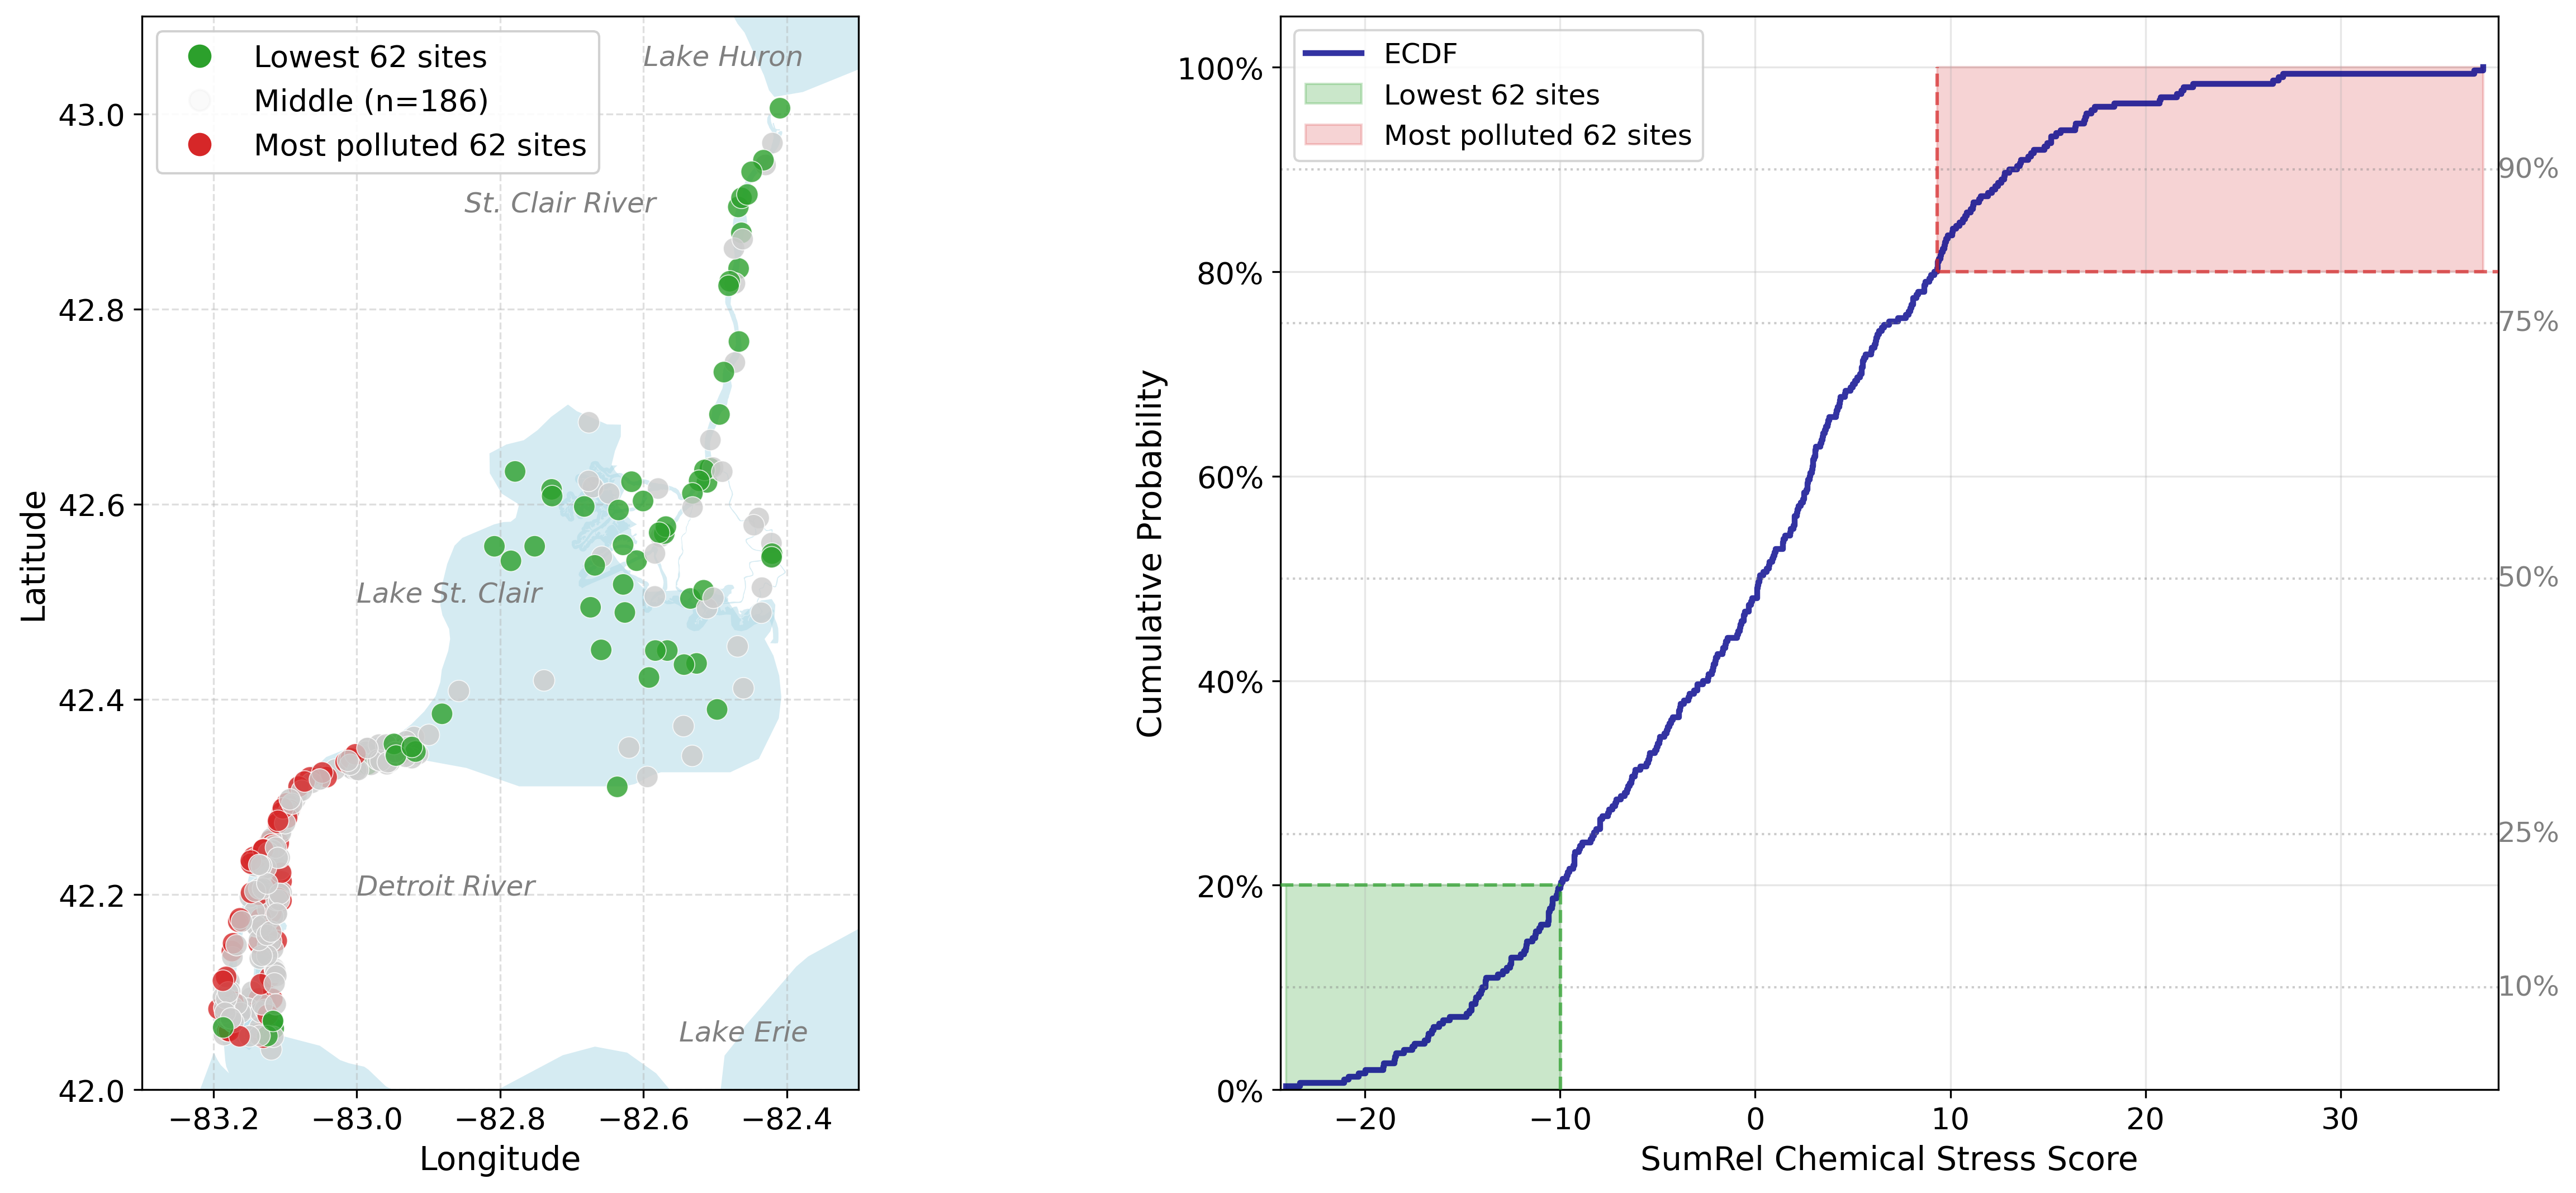

In [11]:
sumrel_corridor_fig, _ = plot_corridor_bifurcation(
    scores=plot_frame["SumRel"],
    lat=plot_frame["Latitude"],
    lon=plot_frame["Longitude"],
    waterbody=plot_frame["Water body"],
    maps_dir=MAPS_DIR,
    score_label="SumRel Chemical Stress Score",
)

sumrel_figure_path = FIGURE_DIR / "ch2_fm1_SumRel_corridor_bifurcation.png"
sumrel_corridor_fig.savefig(sumrel_figure_path, dpi=300, bbox_inches="tight")

print(f"Saved SumRel figure to: {sumrel_figure_path}")
plt.show()

## 5.3 Draw and save MaxRel bifurcation figure

Saved MaxRel figure to: ../figures/ch2_fm1_MaxRel_corridor_bifurcation.png


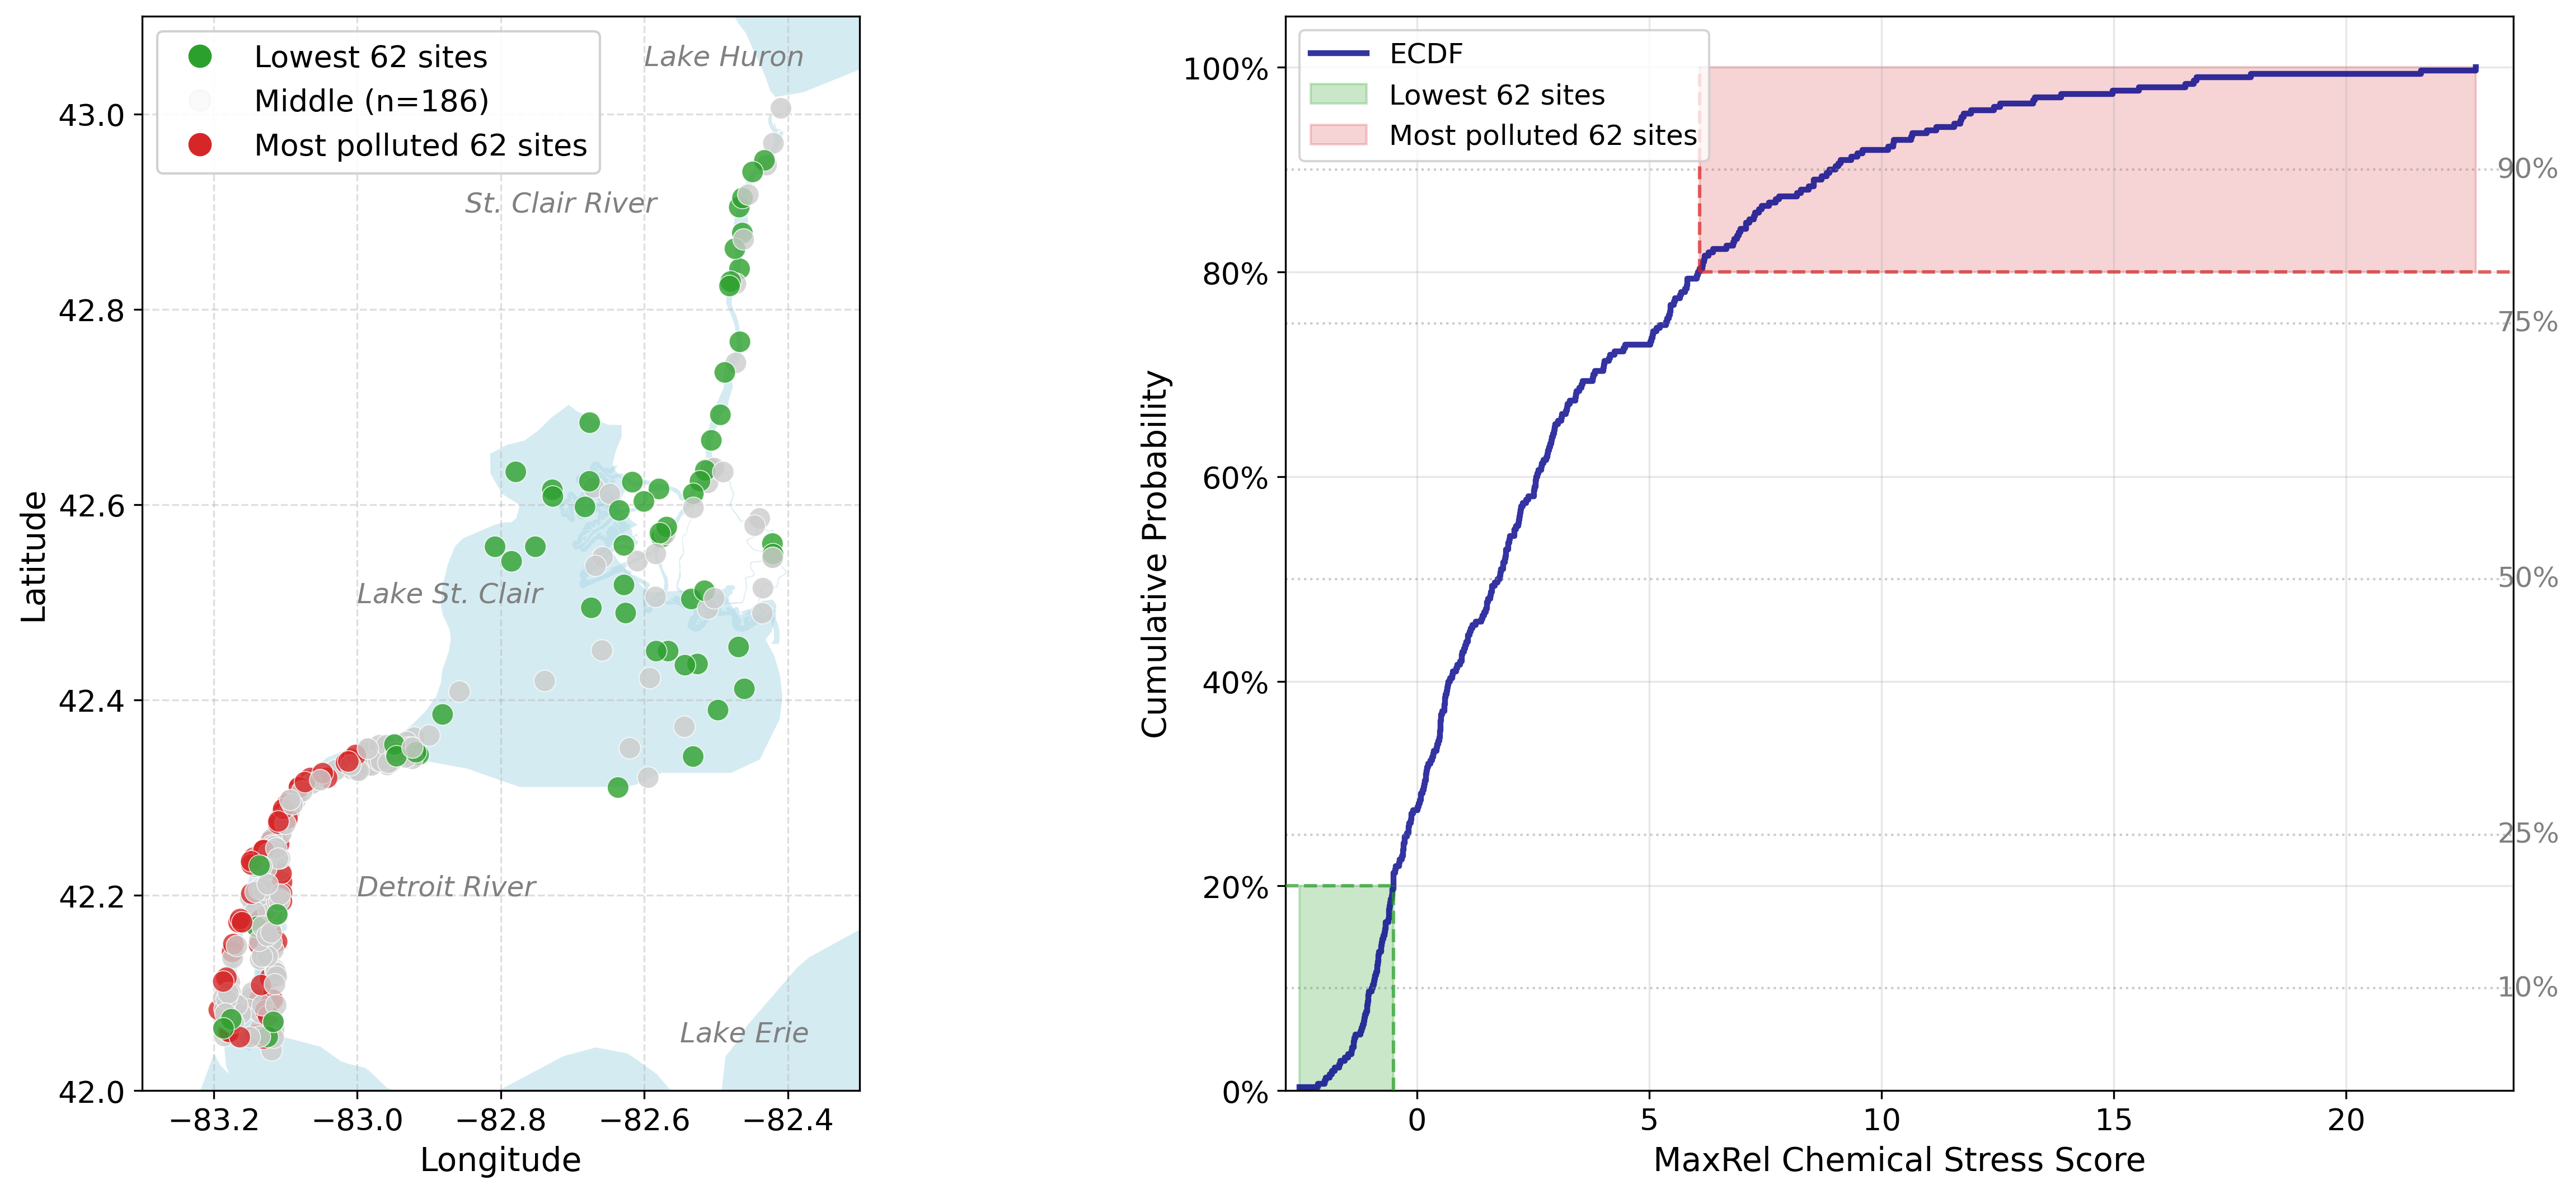

In [12]:
maxrel_corridor_fig, _ = plot_corridor_bifurcation(
    scores=plot_frame["MaxRel"],
    lat=plot_frame["Latitude"],
    lon=plot_frame["Longitude"],
    waterbody=plot_frame["Water body"],
    maps_dir=MAPS_DIR,
    score_label="MaxRel Chemical Stress Score",
)

maxrel_figure_path = FIGURE_DIR / "ch2_fm1_MaxRel_corridor_bifurcation.png"
maxrel_corridor_fig.savefig(maxrel_figure_path, dpi=300, bbox_inches="tight")

print(f"Saved MaxRel figure to: {maxrel_figure_path}")
plt.show()

# 6. Execution summary

At the end of a successful run, this notebook produces:

```text
../results/ch2_fw1_rotated_loading_table.xlsx
../artifacts/A1_stressors_and_scores.xlsx
../figures/ch2_fm1_SumRel_corridor_bifurcation.png
../figures/ch2_fm1_MaxRel_corridor_bifurcation.png
```